# 🐷 Pig Posture Recognition – ConvNeXt DANN + UDA + Focal Loss

**Ansatz:** Domain Adversarial Neural Network (DANN) mit Unsupervised Domain Adaptation (UDA). Das Modell trainiert gleichzeitig auf gelabelten Train-Daten (Haltung + Kamera) und ungelebelten Test-Daten (nur Kamera). So wird das Netzwerk dazu gezwungen, Features zu lernen, die komplett kameraunabhängig sind – der Schlüssel, um auf unbekannten Kameras (Kaggle Test-Set) gut abzuschneiden!

**Neuerungen in dieser Version für über 80% Leaderboard:**
1. **384x384 Auflösung** (`convnext_base.fb_in22k_ft_in1k_384`) für feinste Haltungs-Details.
2. **Focal Loss** statt CrossEntropy Loss, um seltene Klassen wie 'Sitting' extrem stark zu priorisieren.
3. **UDA Test-Set Integration**, der Test-Datensatz läuft live beim DANN mit durch!
4. **Multi-GPU + SSL Fix** integriert.

In [1]:
import gc
import torch

# Clear GPU memory from previous runs before doing anything else
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("🧹 GPU Memory bereinigt.")

🧹 GPU Memory bereinigt.


## ⚙️ Configuration

In [2]:
TAG = "T2"

DATA_ROOT = "/datasets/multi-view-pig-posture-recognition"

if TAG == "T1":
    CSV_PATH = f"{DATA_ROOT}/train1.csv"
    IMG_DIR  = f"{DATA_ROOT}/train1_images"
else:
    CSV_PATH = f"{DATA_ROOT}/train2.csv"
    IMG_DIR  = f"{DATA_ROOT}/train2_images"

TEST_CSV_PATH = f"{DATA_ROOT}/test.csv"
TEST_IMG_DIR  = f"{DATA_ROOT}/test_images"

OUTPUT_DIR = f"runs/convnext_dann_uda4_{TAG.lower()}"

# 384x384 Modell für noch präzisere Schweine-Haltungserkennung auf 4 GPUs
MODEL_NAME     = "convnext_base.fb_in22k_ft_in1k_384"
IMG_SIZE       = 288
BATCH_SIZE     = 64  # Reduziert für 384x384
EPOCHS         = 20
LR             = 1e-4 # Weniger aggressiv bei UDA
WARMUP_EPOCHS  = 2
VAL_FRAC       = 0.10
LABEL_SMOOTH   = 0.10
MIXUP_ALPHA    = 0.30
PAD_RATIO      = 0.25
NUM_WORKERS    = 12
SEED           = 42

NUM_CLASSES    = 5
CLASS_NAMES    = ["Lateral_lying_left", "Lateral_lying_right",
                  "Sitting", "Standing", "Sternal_lying"]

# Starker Domain-Fokus, da wir echtes Test-Set einbauen
LAMBDA_DOMAIN_MAX = 0.5
FOCAL_GAMMA    = 2.0  # Wie stark das Modell auf schwere Fehler fokussieren soll

print(f"Tag: {TAG}  |  Model: {MODEL_NAME}  |  ImgSize: {IMG_SIZE}  |  Batch: {BATCH_SIZE}")

Tag: T2  |  Model: convnext_base.fb_in22k_ft_in1k_384  |  ImgSize: 288  |  Batch: 64


## 📦 Install Dependencies

In [3]:
!pip install timm tqdm scikit-learn pandas pillow matplotlib -q

## 📚 Imports, GPU Check & SSL Fix

In [4]:
import ast, random, re
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
from collections import Counter
import os
import ssl
import urllib3
import requests

# --- SSL Fix für Zertifikat-Fehler ---
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
ssl._create_default_https_context = ssl._create_unverified_context
old_request = requests.Session.request
def new_request(self, method, url, **kwargs):
    kwargs['verify'] = False
    return old_request(self, method, url, **kwargs)
requests.Session.request = new_request
# --------------------------------------

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import torchvision.transforms as T
import timm

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
import warnings
warnings.filterwarnings("ignore")

NUM_GPUS = torch.cuda.device_count()
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
DEVICE_IDS = list(range(NUM_GPUS))

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPUs detected: {NUM_GPUS}")
if torch.cuda.is_available():
    for i in DEVICE_IDS:
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

<jemalloc>: Unsupported system page size


CUDA available: True
GPUs detected: 4
  GPU 0: Tesla V100-SXM2-16GB
  GPU 1: Tesla V100-SXM2-16GB
  GPU 2: Tesla V100-SXM2-16GB
  GPU 3: Tesla V100-SXM2-16GB


## 🔒 Reproducibility

In [5]:
def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(SEED)
os.makedirs(OUTPUT_DIR, exist_ok=True)

## 🔍 Load Data & Extract Global Domain IDs (Train + Test)

In [6]:
def extract_domain(image_id):
    name = os.path.splitext(image_id)[0]
    match = re.match(r'^(cam\d+|view\d+|camera\d+)', name, re.IGNORECASE)
    if match: return match.group(1).lower()
    match = re.match(r'^(.+?)_?\d+$', name)
    if match: return match.group(1).lower()
    parts = name.split('_')
    if len(parts) > 1: return parts[0].lower()
    return name.lower()

df_train = pd.read_csv(CSV_PATH)
df_test = pd.read_csv(TEST_CSV_PATH)

df_train['domain_str'] = df_train['image_id'].apply(extract_domain)
df_test['domain_str']  = df_test['image_id'].apply(extract_domain)

# Globales Domain Dictionary über Train + Test
all_domains = sorted(set(df_train['domain_str'].unique()) | set(df_test['domain_str'].unique()))
domain_to_id = {name: i for i, name in enumerate(all_domains)}

df_train['domain_id'] = df_train['domain_str'].map(domain_to_id)
df_test['domain_id']  = df_test['domain_str'].map(domain_to_id)

NUM_DOMAINS = len(all_domains)
print(f"Total Train: {len(df_train)}  |  Total Test: {len(df_test)}")
print(f"\n{NUM_DOMAINS} global domains detected across Train & Test datasets.\n")

print("Class distribution (Train):")
for c in range(NUM_CLASSES):
    cnt = (df_train["class_id"] == c).sum()
    print(f"  {c} - {CLASS_NAMES[c]:<22} {cnt:>5}")

Total Train: 23450  |  Total Test: 11708

40 global domains detected across Train & Test datasets.

Class distribution (Train):
  0 - Lateral_lying_left      3083
  1 - Lateral_lying_right     3435
  2 - Sitting                  695
  3 - Standing                9928
  4 - Sternal_lying           6309


## 🎯 Focal Loss & Gradient Reversal Layer

In [7]:
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, reduction='mean', label_smoothing=0.0):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=weight, reduction='none', label_smoothing=label_smoothing)
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        if self.reduction == 'mean': return focal_loss.mean()
        return focal_loss.sum()

class GradientReversalFunction(torch.autograd.Function):
    @staticmethod
    def forward(ctx, x, lambda_):
        ctx.lambda_ = lambda_
        return x.clone()
    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.lambda_ * grad_output, None

class GradientReversalLayer(nn.Module):
    def __init__(self, lambda_=1.0):
        super().__init__()
        self.lambda_ = lambda_
    def forward(self, x):
        return GradientReversalFunction.apply(x, self.lambda_)

def get_lambda(epoch, max_epochs):
    p = epoch / max_epochs
    return LAMBDA_DOMAIN_MAX * (2.0 / (1.0 + np.exp(-10.0 * p)) - 1.0)

## 🧠 ConvNeXt-DANN Model

In [8]:
class ConvNeXtDANN(nn.Module):
    def __init__(self, model_name, num_classes, num_domains, drop_rate=0.3):
        super().__init__()
        self.features = timm.create_model(model_name, pretrained=True, num_classes=0)
        feat_dim = self.features.num_features
        self.posture_head = nn.Sequential(
            nn.LayerNorm(feat_dim), nn.Dropout(drop_rate),
            nn.Linear(feat_dim, 512), nn.GELU(), nn.Dropout(drop_rate),
            nn.Linear(512, num_classes)
        )
        self.grl = GradientReversalLayer()
        self.domain_head = nn.Sequential(
            nn.LayerNorm(feat_dim), nn.Dropout(drop_rate),
            nn.Linear(feat_dim, 512), nn.GELU(), nn.Dropout(drop_rate),
            nn.Linear(512, 256), nn.GELU(), nn.Dropout(drop_rate),
            nn.Linear(256, num_domains)
        )
        print(f"ConvNeXtDANN: feat={feat_dim}, posture={num_classes}, domains={num_domains}")

    def forward(self, x, lambda_=1.0):
        features = self.features(x)
        posture_logits = self.posture_head(features)
        self.grl.lambda_ = lambda_
        domain_logits = self.domain_head(self.grl(features))
        return posture_logits, domain_logits

    def predict_posture(self, x):
        return self.posture_head(self.features(x))

## 🗂️ Dataset & Augmentations

In [9]:
class PigPostureDANNDataset(Dataset):
    def __init__(self, df, img_dir, transform=None, pad_ratio=0.25):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.pad_ratio = pad_ratio

    def __len__(self): return len(self.df)

    def _crop(self, img, bbox):
        W, H = img.size
        x, y, w, h = [float(v) for v in ast.literal_eval(bbox)]
        px, py = w * self.pad_ratio, h * self.pad_ratio
        x1 = max(0, int(x - px)); y1 = max(0, int(y - py))
        x2 = min(W, int(x+w+px)); y2 = min(H, int(y+h+py))
        return img.crop((x1, y1, x2, y2))

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.img_dir, row["image_id"])).convert("RGB")
        crop = self._crop(img, row["bbox"])
        if self.transform: crop = self.transform(crop)
        cid = int(row["class_id"]) if "class_id" in row else -1
        return crop, cid, int(row["domain_id"])

def get_train_transform(size=IMG_SIZE):
    return T.Compose([
        T.Resize((size + 48, size + 48)), T.RandomCrop(size),
        T.RandomHorizontalFlip(p=0.5), T.RandomVerticalFlip(p=0.3),
        T.RandomRotation(degrees=25),
        T.RandomAffine(degrees=0, scale=(0.85, 1.15)),
        T.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.4, hue=0.08),
        T.RandomGrayscale(p=0.1),
        T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.0)),
        T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        T.RandomErasing(p=0.3, scale=(0.02, 0.2)),
    ])

def get_val_transform(size=IMG_SIZE):
    return T.Compose([
        T.Resize((size, size)), T.ToTensor(),
        T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])


## ✂️ Loaders (Train, Val, Unlabeled Test)

In [10]:
train_df, val_df = train_test_split(
    df_train, test_size=VAL_FRAC, stratify=df_train["class_id"], random_state=SEED
)

train_ds = PigPostureDANNDataset(train_df, IMG_DIR, transform=get_train_transform(), pad_ratio=PAD_RATIO)
val_ds   = PigPostureDANNDataset(val_df,   IMG_DIR, transform=get_val_transform(),   pad_ratio=PAD_RATIO)
test_uda = PigPostureDANNDataset(df_test,  TEST_IMG_DIR, transform=get_train_transform(), pad_ratio=PAD_RATIO)

train_loader    = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, drop_last=True)
val_loader      = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
uda_test_loader = DataLoader(test_uda, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, drop_last=True)

print(f"Batches an train: {len(train_loader)} | UDA Test batches: {len(uda_test_loader)}")

Batches an train: 329 | UDA Test batches: 182


## 🧠 Create Model, Loss & Optimizer (Multi-GPU)

In [11]:
model = ConvNeXtDANN(MODEL_NAME, NUM_CLASSES, NUM_DOMAINS)

if NUM_GPUS > 1:
    print(f"Verwende nn.DataParallel für {NUM_GPUS} GPUs!")
    model = nn.DataParallel(model, device_ids=DEVICE_IDS)
model = model.to(DEVICE)

counts = Counter(train_df["class_id"].tolist())
total = len(train_df)
# Fokus auf Minderheitsklassen wie Sitting
weights = torch.tensor(
    [total / (NUM_CLASSES * max(counts.get(c, 1), 1)) for c in range(NUM_CLASSES)], 
    dtype=torch.float32
).to(DEVICE)
print(f"Class weights: {[f'{w:.2f}' for w in weights.cpu()]}")

# FOCAL LOSS anstelle Standard CE für harte Samples
posture_criterion       = FocalLoss(weight=weights, gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTH)
posture_criterion_unw   = FocalLoss(gamma=FOCAL_GAMMA) # für mixup
domain_criterion        = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-2)

def warmup_cosine_schedule(epoch):
    if epoch < WARMUP_EPOCHS: return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / max(EPOCHS - WARMUP_EPOCHS, 1)
    return 0.5 * (1.0 + np.cos(np.pi * progress))

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=warmup_cosine_schedule)
scaler = GradScaler()

ConvNeXtDANN: feat=1024, posture=5, domains=40
Verwende nn.DataParallel für 4 GPUs!
Class weights: ['1.52', '1.37', '6.74', '0.47', '0.74']


## 🛠️ Training (mit UDA) & Validation

In [12]:
def mixup_data(x, y, alpha=0.3):
    if alpha <= 0: return x, y, y, 1.0
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(x.size(0)).to(x.device)
    return lam * x + (1 - lam) * x[idx], y, y[idx], lam

def mixup_loss(crit, pred, y_a, y_b, lam):
    return lam * crit(pred, y_a) + (1 - lam) * crit(pred, y_b)

def train_one_epoch(model, loader, uda_loader, optimizer, scaler, epoch):
    model.train()
    lam_grl = get_lambda(epoch, EPOCHS)
    p_loss_sum, d_loss_sum = 0.0, 0.0
    p_preds, p_labels, d_preds, d_labels = [], [], [], []
    
    uda_iter = iter(uda_loader)
    
    for imgs, plabels, dlabels in tqdm(loader, desc="  Train (Labeled+UDA)", leave=False):
        imgs, plabels, dlabels = imgs.to(DEVICE), plabels.to(DEVICE), dlabels.to(DEVICE)
        
        # UDA Test Set abgreifen
        try:
            t_imgs, _, t_dlabels = next(uda_iter)
        except StopIteration:
            uda_iter = iter(uda_loader)
            t_imgs, _, t_dlabels = next(uda_iter)
            
        t_imgs, t_dlabels = t_imgs.to(DEVICE), t_dlabels.to(DEVICE)

        # MixUp auf die labeled data
        mixed, y_a, y_b, lam = mixup_data(imgs, plabels, alpha=MIXUP_ALPHA)
        
        optimizer.zero_grad()
        with autocast():
            # 1. Forward labeled Data (Posture + Domain)
            p_logits, d_logits = model(mixed, lambda_=lam_grl)
            p_loss = mixup_loss(posture_criterion_unw, p_logits, y_a, y_b, lam)
            d_loss_labeled = domain_criterion(d_logits, dlabels)
            
            # 2. Forward unlabeled Test Data (Only Domain)
            _, t_d_logits = model(t_imgs, lambda_=lam_grl)
            d_loss_unlabeled = domain_criterion(t_d_logits, t_dlabels)
            
            # Gesamt-Loss
            d_loss = 0.5 * d_loss_labeled + 0.5 * d_loss_unlabeled
            loss = p_loss + d_loss
            
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer); scaler.update()
        
        p_loss_sum += p_loss.item() * imgs.size(0)
        d_loss_sum += d_loss.item() * (imgs.size(0) * 2)
        
        p_preds.extend(p_logits.argmax(1).cpu().numpy())
        p_labels.extend(y_a.cpu().numpy())
        d_preds.extend(d_logits.argmax(1).cpu().numpy())
        d_labels.extend(dlabels.cpu().numpy())
        
    n = len(loader.dataset)
    return {'p_loss': p_loss_sum/n, 'd_loss': d_loss_sum/(n*2),
            'p_f1': f1_score(p_labels, p_preds, average='macro', zero_division=0),
            'd_acc': np.mean(np.array(d_preds)==np.array(d_labels)), 'lambda': lam_grl}

@torch.no_grad()
def validate(model, loader, epoch):
    model.eval()
    lam_grl = get_lambda(epoch, EPOCHS)
    p_loss_sum, d_loss_sum = 0.0, 0.0
    p_preds, p_labels, d_preds, d_labels = [], [], [], []
    for imgs, plabels, dlabels in tqdm(loader, desc="  Val  ", leave=False):
        imgs, plabels, dlabels = imgs.to(DEVICE), plabels.to(DEVICE), dlabels.to(DEVICE)
        with autocast():
            p_logits, d_logits = model(imgs, lambda_=lam_grl)
            p_loss = posture_criterion(p_logits, plabels)
            d_loss = domain_criterion(d_logits, dlabels)
        p_loss_sum += p_loss.item() * imgs.size(0)
        d_loss_sum += d_loss.item() * imgs.size(0)
        p_preds.extend(p_logits.argmax(1).cpu().numpy())
        p_labels.extend(plabels.cpu().numpy())
        d_preds.extend(d_logits.argmax(1).cpu().numpy())
        d_labels.extend(dlabels.cpu().numpy())
    n = len(loader.dataset)
    return {'p_loss': p_loss_sum/n, 'd_loss': d_loss_sum/n,
            'p_f1': f1_score(p_labels, p_preds, average='macro', zero_division=0),
            'd_acc': np.mean(np.array(d_preds)==np.array(d_labels))}, p_preds, p_labels

## 🚀 Training Loop

In [13]:
best_val_f1 = 0.0
log = []

for epoch in range(1, EPOCHS + 1):
    tm = train_one_epoch(model, train_loader, uda_test_loader, optimizer, scaler, epoch)
    vm, _, _ = validate(model, val_loader, epoch)
    scheduler.step()
    lr = scheduler.get_last_lr()[0]

    mark = "★" if vm['p_f1'] > best_val_f1 else " "
    print(f"{mark} E{epoch:02d}/{EPOCHS} | "
          f"Train p_f1={tm['p_f1']:.4f} d_acc={tm['d_acc']:.3f} | "
          f"Val p_f1={vm['p_f1']:.4f} d_acc={vm['d_acc']:.3f} | "
          f"λ={tm['lambda']:.4f} lr={lr:.2e}")

    log.append(dict(epoch=epoch, train_p_loss=tm['p_loss'], train_p_f1=tm['p_f1'],
                    train_d_loss=tm['d_loss'], train_d_acc=tm['d_acc'],
                    val_p_loss=vm['p_loss'], val_p_f1=vm['p_f1'],
                    val_d_acc=vm['d_acc'], lambda_=tm['lambda'], lr=lr))

    if vm['p_f1'] > best_val_f1:
        best_val_f1 = vm['p_f1']
        model_to_save = model.module if isinstance(model, nn.DataParallel) else model
        torch.save({
            "epoch": epoch, "model": model_to_save.state_dict(),
            "optimizer": optimizer.state_dict(),
            "val_f1": vm['p_f1'], "val_domain_acc": vm['d_acc'],
            "model_name": MODEL_NAME, "num_classes": NUM_CLASSES,
            "num_domains": NUM_DOMAINS, "tag": TAG,
            "architecture": "ConvNeXtDANN_UDA_Focal",
            "img_size": IMG_SIZE
        }, os.path.join(OUTPUT_DIR, "best_model.pth"))
        print(f"  → Saved (f1={vm['p_f1']:.4f}, d_acc={vm['d_acc']:.3f})")

print(f"\n✅ Done. Best Val F1: {best_val_f1:.4f}")
pd.DataFrame(log).to_csv(os.path.join(OUTPUT_DIR, "training_log.csv"), index=False)

★ E01/20 | Train p_f1=0.3456 d_acc=0.204 | Val p_f1=0.7638 d_acc=0.256 | λ=0.1225 lr=1.00e-04
  → Saved (f1=0.7638, d_acc=0.256)


  E02/20 | Train p_f1=0.4378 d_acc=0.202 | Val p_f1=0.7535 d_acc=0.297 | λ=0.2311 lr=1.00e-04


★ E03/20 | Train p_f1=0.4837 d_acc=0.210 | Val p_f1=0.8585 d_acc=0.246 | λ=0.3176 lr=9.92e-05
  → Saved (f1=0.8585, d_acc=0.246)


★ E04/20 | Train p_f1=0.5387 d_acc=0.207 | Val p_f1=0.8893 d_acc=0.243 | λ=0.3808 lr=9.70e-05
  → Saved (f1=0.8893, d_acc=0.243)


★ E05/20 | Train p_f1=0.5341 d_acc=0.217 | Val p_f1=0.8924 d_acc=0.224 | λ=0.4241 lr=9.33e-05
  → Saved (f1=0.8924, d_acc=0.224)


...

  E16/20 | Train p_f1=0.5953 d_acc=0.223 | Val p_f1=0.9258 d_acc=0.224 | λ=0.4997 lr=1.17e-05


  E17/20 | Train p_f1=0.5849 d_acc=0.223 | Val p_f1=0.9297 d_acc=0.225 | λ=0.4998 lr=6.70e-06


★ E18/20 | Train p_f1=0.5788 d_acc=0.224 | Val p_f1=0.9342 d_acc=0.225 | λ=0.4999 lr=3.02e-06
  → Saved (f1=0.9342, d_acc=0.225)


  E19/20 | Train p_f1=0.5687 d_acc=0.223 | Val p_f1=0.9295 d_acc=0.225 | λ=0.4999 lr=7.60e-07


  E20/20 | Train p_f1=0.6036 d_acc=0.223 | Val p_f1=0.9321 d_acc=0.225 | λ=0.5000 lr=0.00e+00

✅ Done. Best Val F1: 0.9342


## 📈 Training Curves

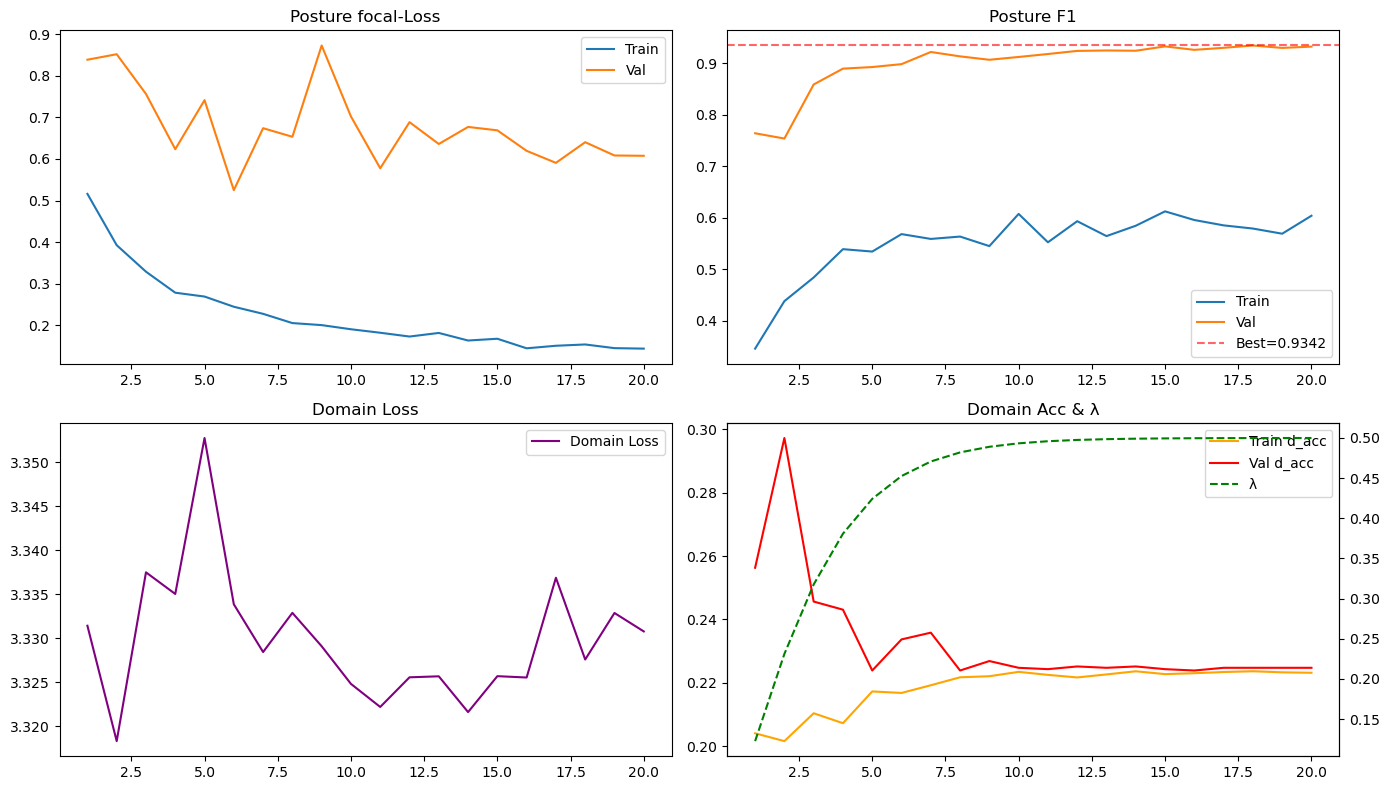

In [14]:
import matplotlib.pyplot as plt
log_df = pd.DataFrame(log)
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes[0,0].plot(log_df['epoch'], log_df['train_p_loss'], label='Train')
axes[0,0].plot(log_df['epoch'], log_df['val_p_loss'], label='Val')
axes[0,0].set_title('Posture focal-Loss'); axes[0,0].legend()
axes[0,1].plot(log_df['epoch'], log_df['train_p_f1'], label='Train')
axes[0,1].plot(log_df['epoch'], log_df['val_p_f1'], label='Val')
axes[0,1].axhline(best_val_f1, color='red', ls='--', alpha=0.6, label=f'Best={best_val_f1:.4f}')
axes[0,1].set_title('Posture F1'); axes[0,1].legend()
axes[1,0].plot(log_df['epoch'], log_df['train_d_loss'], color='purple', label='Domain Loss')
axes[1,0].set_title('Domain Loss'); axes[1,0].legend()
ax2 = axes[1,1].twinx()
l1, = axes[1,1].plot(log_df['epoch'], log_df['train_d_acc'], color='orange', label='Train d_acc')
l2, = axes[1,1].plot(log_df['epoch'], log_df['val_d_acc'], color='red', label='Val d_acc')
l3, = ax2.plot(log_df['epoch'], log_df['lambda_'], color='green', ls='--', label='λ')
axes[1,1].set_title('Domain Acc & λ'); axes[1,1].legend(handles=[l1,l2,l3])
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=120)
plt.show()

## 📊 Classification Report

In [15]:
ckpt = torch.load(os.path.join(OUTPUT_DIR, 'best_model.pth'), map_location=DEVICE)
eval_model = ConvNeXtDANN(MODEL_NAME, NUM_CLASSES, NUM_DOMAINS)
eval_model.load_state_dict(ckpt['model'])
eval_model = eval_model.to(DEVICE).eval()
_, val_preds, val_labels = validate(eval_model, val_loader, EPOCHS)
print(classification_report(val_labels, val_preds, target_names=CLASS_NAMES))
print(f"Best: Epoch {ckpt['epoch']}, F1={ckpt['val_f1']:.4f}, Domain Acc={ckpt.get('val_domain_acc','N/A')}")

ConvNeXtDANN: feat=1024, posture=5, domains=40


                     precision    recall  f1-score   support

 Lateral_lying_left       0.94      0.94      0.94       308
Lateral_lying_right       0.94      0.96      0.95       344
            Sitting       0.95      0.77      0.85        69
           Standing       0.98      0.99      0.99       993
      Sternal_lying       0.95      0.94      0.94       631

           accuracy                           0.96      2345
          macro avg       0.95      0.92      0.93      2345
       weighted avg       0.96      0.96      0.96      2345

Best: Epoch 18, F1=0.9342, Domain Acc=0.22473347547974415
